<a href="https://colab.research.google.com/github/dhurai1085/python-practice/blob/main/employee_performance_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
url = 'https://raw.githubusercontent.com/dhurai1085/python-analytics-portfolio/refs/heads/main/raw_dataset/Messy_Employee_dataset.csv'
df = pd.read_csv(url)
df_copy = df.copy()
df.head(10)

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False
5,EMP1005,Alice,Garcia,40.0,Sales-Texas,Inactive,6/10/2020,88642.84,alice.garcia@example.com,-5409003485,Good,False
6,EMP1006,Frank,Jones,NaN,Admin-Nevada,Active,4/3/2020,96288.43,frank.jones@example.com,-4518376063,Good,False
7,EMP1007,Bob,Jones,30.0,Cloud Tech-Florida,Inactive,7/17/2022,94497.91,bob.jones@example.com,-4134327559,Average,True
8,EMP1008,Frank,Davis,35.0,Admin-Nevada,Inactive,12/8/2023,115565.82,frank.davis@example.com,-4177656123,Excellent,True
9,EMP1009,Charlie,Johnson,NaN,DevOps-New York,Active,8/4/2022,76561.88,charlie.johnson@example.com,-8156985699,Excellent,True


In [3]:
df.columns

Index(['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Department_Region',
       'Status', 'Join_Date', 'Salary', 'Email', 'Phone', 'Performance_Score',
       'Remote_Work'],
      dtype='object')

In [4]:
df.shape
df['Age'].unique()

array([25., nan, 40., 30., 35.])

In [5]:
df['Employee_ID'].duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

,0
Employee_ID,object
First_Name,object
Last_Name,object
Age,float64
Department_Region,object
Status,object
Join_Date,object
Salary,float64
Email,object
Phone,int64


In [7]:
df['Join_Date'] = df['Join_Date'].astype('datetime64[ns]')
df['Join_Date'].dtype

dtype('<M8[ns]')

In [8]:
# imputing age column

print(df['Age'].isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())

211


In [9]:
# imputing salary column

df['Salary'].isnull().sum()

np.int64(24)

In [10]:
# splitting department-region column

df[['Department','State']] = df['Department_Region'].str.split('-',expand = True)
df[['Department','State']].head(5)

,Department,State
0,DevOps,California
1,Finance,Texas
2,Admin,Nevada
3,Admin,Nevada
4,Cloud Tech,Florida


In [11]:
df['Department'].isnull().sum()

np.int64(0)

In [12]:
df['State'].isnull().sum()

np.int64(0)

In [13]:
df.isnull().sum()

,0
Employee_ID,0
First_Name,0
Last_Name,0
Age,0
Department_Region,0
Status,0
Join_Date,0
Salary,24
Email,0
Phone,0


In [14]:
# imputing salary column

df['Salary']  = df.groupby('Department')['Salary'].transform(lambda x : x.fillna(x.median()))
df['Salary'].isnull().sum()

np.int64(0)

In [15]:
df.dtypes

,0
Employee_ID,object
First_Name,object
Last_Name,object
Age,float64
Department_Region,object
Status,object
Join_Date,datetime64[ns]
Salary,float64
Email,object
Phone,int64


In [16]:
df.head(5)

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work,Department,State
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,2021-04-02,59767.65,bob.davis@example.com,-1651623197,Average,True,DevOps,California
1,EMP1001,Bob,Brown,30.0,Finance-Texas,Active,2020-07-10,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Finance,Texas
2,EMP1002,Alice,Jones,30.0,Admin-Nevada,Pending,2023-12-07,88145.90,alice.jones@example.com,-5596363211,Good,True,Admin,Nevada
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,2021-11-27,69450.99,eva.davis@example.com,-3476490784,Good,True,Admin,Nevada
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,2022-01-05,109324.61,frank.williams@example.com,-1586734256,Poor,False,Cloud Tech,Florida


In [17]:
dept_wise_salary = df.groupby('Department')['Salary'].sum()
df_salary = pd.DataFrame(dept_wise_salary)
df_salary

,Salary
Department,
Admin,14152690.92
Cloud Tech,12407239.96
DevOps,16256138.25
Finance,13983455.24
HR,14616173.93
Sales,15467470.29


In [18]:
df['Age'] = df['Age'].astype(np.int64)
df['Age'].dtype
df['Age'].unique()

array([25, 30, 40, 35])

In [19]:
# creating age group column

df["Age_group"] = None  # start clean

df.loc[(df["Age"] >= 25) & (df["Age"] <= 30), "Age_group"] = "25-30"
df.loc[(df["Age"] > 30) & (df["Age"] <= 35), "Age_group"] = "31-35"
df.loc[(df["Age"] > 35) & (df["Age"] <= 40), "Age_group"] = "36-40"



In [20]:
df['Age_group'].value_counts()

,count
Age_group,
25-30,622
36-40,210
31-35,188


In [21]:
df['Age'].describe()

,Age
count,1020.000000
mean,31.970588
std,5.136901
min,25.000000
25%,30.000000
50%,30.000000
75%,35.000000
max,40.000000


In [22]:
age_group_salary = df.groupby('Age_group')['Salary'].sum()
df_age_group_salary = pd.DataFrame(age_group_salary)
df_age_group_salary.style.format("{:.2f}")

,Salary
Age_group,
25-30,52479115.85
31-35,15843870.24
36-40,18560182.50


In [23]:
df_status_salary = df.groupby('Status')['Salary'].sum()
pd.DataFrame(df_status_salary)
df_status_salary

,Salary
Status,
Active,29972211.91
Inactive,26386344.13
Pending,30524612.55


In [24]:
df_performance_salary = df.groupby('Performance_Score')['Salary'].sum()
df_performance_salary = pd.DataFrame(df_performance_salary)
df_performance_salary.style.format('{:.2f}')


,Salary
Performance_Score,
Average,22488739.70
Excellent,22715474.82
Good,23306491.18
Poor,18372462.89


In [25]:
# creating new column Exp_years

df['Exp_years'] = round((pd.to_datetime('today') - df['Join_Date']).dt.days / 365.25 , 2)
df['Exp_years'].value_counts()

,count
Exp_years,
1.59,8
4.45,8
1.86,8
2.67,7
1.79,7
...,...
2.50,1
2.61,1
5.45,1


In [26]:
df_exp_salary =  pd.DataFrame(df.groupby('Exp_years')['Salary'].sum())
df_exp_salary

,Salary
Exp_years,
1.31,291009.23
1.32,174143.49
1.33,218134.01
1.34,374037.06
1.35,155658.54
...,...
6.25,86163.91
6.26,281321.95
6.27,191148.43


In [27]:
df.isnull().sum()

,0
Employee_ID,0
First_Name,0
Last_Name,0
Age,0
Department_Region,0
Status,0
Join_Date,0
Salary,0
Email,0
Phone,0


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Employee_ID        1020 non-null   object        
 1   First_Name         1020 non-null   object        
 2   Last_Name          1020 non-null   object        
 3   Age                1020 non-null   int64         
 4   Department_Region  1020 non-null   object        
 5   Status             1020 non-null   object        
 6   Join_Date          1020 non-null   datetime64[ns]
 7   Salary             1020 non-null   float64       
 8   Email              1020 non-null   object        
 9   Phone              1020 non-null   int64         
 10  Performance_Score  1020 non-null   object        
 11  Remote_Work        1020 non-null   bool          
 12  Department         1020 non-null   object        
 13  State              1020 non-null   object        
 14  Age_grou

# Visualization

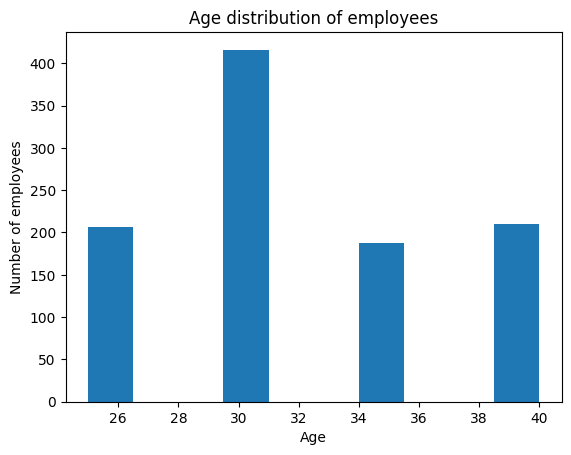

In [30]:
# using histogram to visual age distribution

plt.hist(df['Age'],bins = 10)
plt.title('Age distribution of employees')
plt.xlabel('Age')
plt.ylabel('Number of employees')
plt.show()

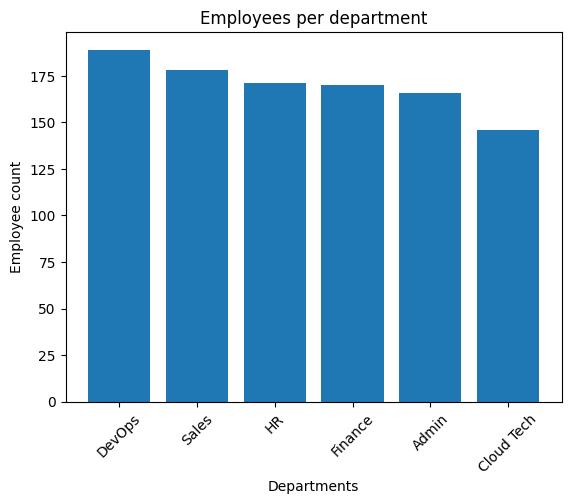

In [31]:
# Visual 2: Bar Chart (Department Distribution)

# “How many employees are in each department?”

depts_counts = df['Department'].value_counts()

plt.bar(depts_counts.index, depts_counts.values)
plt.title('Employees per department')
plt.xlabel('Departments')
plt.ylabel('Employee count')
plt.xticks(rotation = 45)
plt.show()

<Axes: xlabel='Department'>

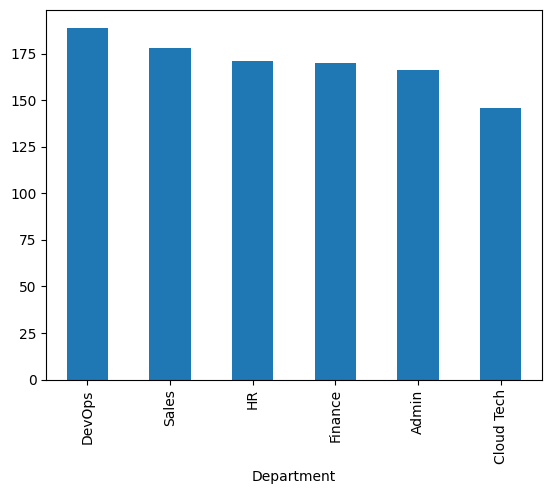

In [32]:
# shorter version

df['Department'].value_counts().plot(kind= 'bar')

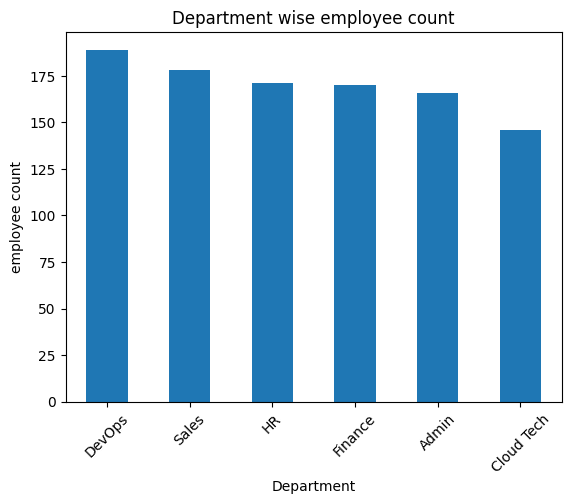

In [33]:
# pandas plot + matplotlib

df['Department'].value_counts().plot(kind= 'bar')
plt.title('Department wise employee count')
plt.xlabel('Department')
plt.ylabel('employee count')
plt.xticks(rotation = 45)
plt.show()


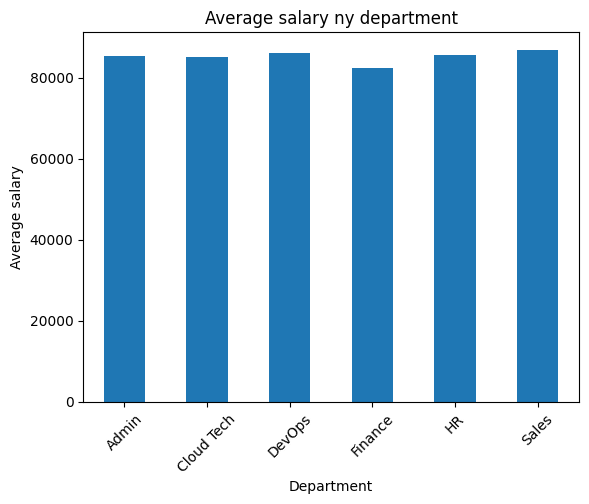

In [34]:
avg_salary = df.groupby('Department')['Salary'].mean()
avg_salary.plot(kind = 'bar')
plt.title('Average salary ny department')
plt.xlabel('Department')
plt.ylabel('Average salary')
plt.xticks(rotation = 45)
plt.show()

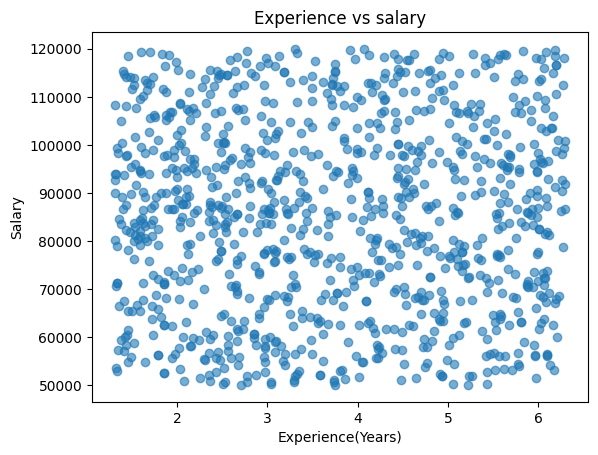

In [36]:
# Experience vs salary analysis using scatter plot

plt.scatter(df['Exp_years'],df['Salary'], alpha = 0.6)
plt.title('Experience vs salary')
plt.xlabel('Experience(Years)')
plt.ylabel('Salary')
plt.show()

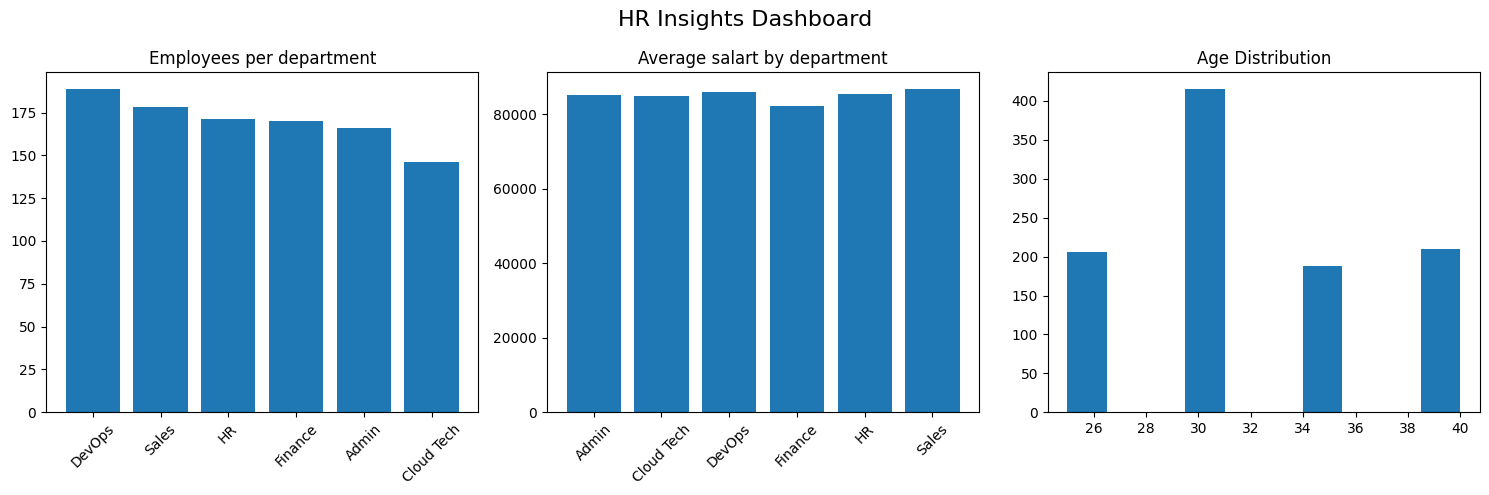

In [44]:
# Dashboard

fig,axes = plt.subplots(1,3,figsize = (15,5))
fig.suptitle("HR Insights Dashboard", fontsize=16)
#chart-1

axes[0].bar(depts_counts.index,depts_counts.values)
axes[0].set_title('Employees per department')
axes[0].tick_params(axis = 'x', rotation = 45)

# Department wise salary analysis

avg_salary = df.groupby('Department')['Salary'].mean()
axes[1].bar(avg_salary.index,avg_salary.values)
axes[1].set_title('Average salart by department')
axes[1].tick_params(axis = 'x', rotation = 45)

# Age distribution
axes[2].hist(df['Age'], bins = 10)
axes[2].set_title('Age Distribution')

plt.tight_layout()
plt.show()
